## INITIAL PROCESSING

In [1]:
# Load MSK data (if not already loaded)
# Uncomment if needed:
import sys,os
import pandas as pd
import numpy as np
# Add parent directory to path to import modules from one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)
import importlib
import public.model_IAI
importlib.reload(public.model_IAI)
from public.model_IAI import *
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("DataLoad").getOrCreate()
# Load the MSK dataset with enhanced cost features
df_msk_spark = spark.read.format("parquet").load("msk_2017_18_full.parquet")
df_og = df_msk_spark.toPandas()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 00:17:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/05 00:17:08 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [3]:
# MSK-specific feature column definitions
# Binary flag columns: comorbidity flags, MSK category flags, medication flags
BIN_FLAG_COLUMNS = get_bin_flag_columns(df_og)
print(BIN_FLAG_COLUMNS)
# MSK doesn't have stage columns like CKD, but we can identify categorical cost pattern/stability columns
STAGE_COLUMNS = []  # MSK doesn't use stage columns

# Categorical columns
CAT_COLUMNS = get_cat_columns(df_og)
# True numeric columns (excluding binary flags and categorical)
TRUE_NUM_COLUMNS = get_true_num_columns(df_og, CAT_COLUMNS,BIN_FLAG_COLUMNS)


# Cost columns (2017 only - exclude 2018 to prevent leakage)
COST_COLUMNS = [
    col for col in df_og.columns 
    if ("cost" in col.lower() or "quarterly" in col.lower() or "increasing" in col.lower() or 
        "decreasing" in col.lower() or "skewness" in col.lower() or "kurtosis" in col.lower() or
        "cv" in col.lower() or "range" in col.lower())
    and "2018" not in col  # Exclude 2018 columns to prevent leakage
]

# Utilization columns (if any)
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" in col.lower() and "2018" not in col]
print("len(UTILIZATION_COLUMNS): ", len(UTILIZATION_COLUMNS))
print("categorical cols: ", CAT_COLUMNS[:10], f"... ({len(CAT_COLUMNS)} total)")
print("stage cols: ", STAGE_COLUMNS)
print("cost cols (sample): ", COST_COLUMNS[:10], f"... ({len(COST_COLUMNS)} total)")

leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
    and c != "ENROLID"
]

print(f"Number of leftover columns: {len(leftover_cols)}")
if len(leftover_cols) > 0:
    print("Leftover columns:", leftover_cols[:20])

# Create cost stratum from 2018 target (if available)
# Check what target columns are available
target_candidates = [col for col in df_og.columns if "2018" in col and ("top" in col.lower() or "pct" in col.lower() or "cost" in col.lower())]
print(f"\nAvailable 2018 target columns: {target_candidates}")

# Use top_2_pct_cost_2018 as target if available, otherwise create from annual_cost_2018_deflated
if "top_2_pct_cost_2018" in df_og.columns:
    target_col = "top_2_pct_cost_2018"
    print(f"Using {target_col} as target column")
elif "annual_cost_2018_deflated" in df_og.columns:
    # Create binary target from annual_cost_2018_deflated
    # Use 98th percentile as threshold (top 2%)
    threshold = df_og["annual_cost_2018_deflated"].quantile(0.98)
    df_og["top_2_pct_cost_2018"] = (df_og["annual_cost_2018_deflated"] >= threshold).astype(int)
    target_col = "top_2_pct_cost_2018"
    print(f"Created {target_col} using threshold ${threshold:,.2f}")
else:
    raise ValueError("No 2018 target column found. Need either 'top_2_pct_cost_2018' or 'annual_cost_2018_deflated'")

# Exclude all columns containing "2018" from features (to prevent leakage)
# Also exclude ENROLID and target column
exclude_cols = ["ENROLID", target_col] + [col for col in df_og.columns 
if "2018" in col] + COST_COLUMNS
feature_cols = [c for c in df_og.columns if c not in exclude_cols]

print(f"\nTotal columns in dataset: {len(df_og.columns)}")
print(f"Columns excluded (leakage prevention): {len(exclude_cols)}, {exclude_cols[:10]}")
print(f"Feature columns: {len(feature_cols)}, {feature_cols[:10]}")

# Check for high correlation with target (optional - can be slow for large datasets)
if len(feature_cols) < 500:  # Only do this for reasonable number of features
    numeric_cols = df_og[feature_cols + [target_col]].select_dtypes(include=["number"]).columns
    if len(numeric_cols) > 0:
        corrs = df_og[numeric_cols].corr()[target_col].abs().sort_values(ascending=False)
        # Columns to drop (very high correlation, likely leakage)
        high_corr_cols = corrs[corrs > 0.95].index.tolist()
        # Remove the target column itself, if present
        high_corr_cols = [col for col in high_corr_cols if col != target_col]
        # Final filtered feature set
        feature_cols = [col for col in feature_cols if col not in high_corr_cols]
        if len(high_corr_cols) > 0:
            print(f"High corr features dropped (corr > 0.95): {high_corr_cols}")

print(f"\nFinal feature count: {len(feature_cols)}")
print(f"Target column: {target_col}")
print(f"Target distribution:\n{df_og[target_col].value_counts()}")

['has_Anemia', 'has_Atherosclerotic_Heart_Disease', 'has_Chronic_Pain', 'has_Depression_Anxiety', 'has_Gastroesophageal_Reflux_Disease', 'has_General_Health_Check', 'has_Hyperlipidemia', 'has_Hypertension', 'has_Long_term_Drug_Therapy', 'has_Obesity', 'has_Sleep_Apnea', 'has_Type_2_Diabetes', 'has_Vitamin_D_Deficiency', 'has_Arthropathies', 'has_Dorsopathies', 'has_Soft_tissue', 'has_Osteopathies', 'has_Other_MSK', 'direct_msk_is_increasing_Q1_Q2_2017', 'direct_msk_is_increasing_Q2_Q3_2017', 'direct_msk_is_increasing_Q3_Q4_2017', 'msk_procedure_is_increasing_Q1_Q2_2017', 'msk_procedure_is_increasing_Q2_Q3_2017', 'msk_procedure_is_increasing_Q3_Q4_2017', 'comorbidity_only_is_increasing_Q1_Q2_2017', 'comorbidity_only_is_increasing_Q2_Q3_2017', 'comorbidity_only_is_increasing_Q3_Q4_2017']
len(UTILIZATION_COLUMNS):  0
categorical cols:  ['direct_msk_cost_pattern_2017', 'direct_msk_cost_stability_2017', 'msk_procedure_cost_pattern_2017', 'msk_procedure_cost_stability_2017', 'comorbidity_onl

In [4]:
# Split data into train/test/val (same as multiobjective_bilevel.ipynb)
# Use the target_col defined in cell 0
TRAIN_TEST_SEED = 123
train_ids, test_ids, train_pd, test_pd = train_test_split_enrol(
    df_og,
    target_col=target_col,  # Use target_col from cell 0 (e.g., "top_2_pct_cost_2018")
    test_size=0.3,
    verbose=False,
    random_state=TRAIN_TEST_SEED
)
print(f"Train shape: {train_pd.shape}, Test shape: {test_pd.shape}")
print("Feature cols:", len(feature_cols))

val_ids, test_ids, val_pd, test_pd = train_test_split_enrol(
    test_pd, 
    target_col=target_col,
    test_size=0.5,
    verbose=False, 
    random_state=TRAIN_TEST_SEED
)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]

print(f"Train: {train_pd.shape}, Val: {val_pd.shape}, Test: {test_pd.shape}")
print(f"Train target distribution:\n{train_pd[target_col].value_counts()}")
print(f"Target column: {target_col}")

Train shape: (175777, 99), Test shape: (75333, 99)
Feature cols: 22
Train: (175777, 99), Val: (37666, 99), Test: (37667, 99)
Train target distribution:
top_2_pct_cost_2018
0    172381
1      3396
Name: count, dtype: int64
Target column: top_2_pct_cost_2018


In [ ]:
# Subgroup analysis: cost distribution of annual_cost_2018_deflated by MSK binary indicators
import matplotlib.pyplot as plt
import seaborn as sns

MSK_SUBGROUP_COLS = [
    "has_Arthropathies",
    "has_Dorsopathies",
    "has_Soft_tissue",
    "has_Osteopathies",
    "has_Other_MSK",
]
COST_COL = "annual_cost_2018_deflated"

# Filter to valid cost values for plotting
df_cost = df_og[[COST_COL] + MSK_SUBGROUP_COLS].dropna(subset=[COST_COL])
# Clip extreme values for clearer visualization (optional)
cost_q99 = df_cost[COST_COL].quantile(0.99)
df_plot = df_cost[df_cost[COST_COL] <= cost_q99].copy()

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(MSK_SUBGROUP_COLS):
    ax = axes[idx]
    if col not in df_plot.columns:
        ax.set_visible(False)
        continue
    for val, label in [(1, "Yes"), (0, "No")]:
        subset = df_plot[df_plot[col] == val][COST_COL]
        if len(subset) > 0:
            ax.hist(subset, bins=50, alpha=0.6, label=f"{col.replace('has_', '')} = {label}", density=True)
    ax.set_xlabel(COST_COL)
    ax.set_ylabel("Density")
    ax.set_title(col.replace("has_", ""))
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide extra subplot if odd number
axes[-1].set_visible(False)
plt.suptitle("Cost distribution by MSK subgroup", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## STEP 1: PRECOMPUTE DISTANCES


In [ ]:
# ============================================================================
# STEP 1: PRECOMPUTE DISTANCES (Minority-Majority and Majority-Majority)
# ============================================================================
import h5py
from sklearn.impute import SimpleImputer
import time
import public.precompute_distances
importlib.reload(public.precompute_distances)
# Import distance computation functions
from public.precompute_distances import (
    get_preprocessor, compute_distances_batched, 
    save_distances_hdf5, precompute_leaf_dnn_hdf5
)


# Create output directory
distance_features = "cost_only"
DISTANCES_DIR = f"./precomputed_distances_msk_{distance_features}/"
os.makedirs(DISTANCES_DIR, exist_ok=True)
PN_H5_PATH = os.path.join(DISTANCES_DIR, "distances_majority_minority.h5")

# Separate minority (cases) and majority (controls)
cases = train_pd[train_pd[target_col] == 1].copy()
controls = train_pd[train_pd[target_col] == 0].copy()

print(f"\nDataset split:")
print(f"  Cases (minority): {len(cases):,}")
print(f"  Controls (majority): {len(controls):,}")
print(f"  Ratio: {len(controls)/len(cases):.2f}:1")

# Prepare feature columns for preprocessing
exclude_cols = [col for col in train_pd.columns if "2018" in col] # and 
random_oct_cols = [
    'msk_procedure_quarterly_min_2017',
    'has_Anemia',
    'has_Atherosclerotic_Heart_Disease',
    'msk_procedure_cost_annual',
    'has_Long_term_Drug_Therapy',
    'has_Depression_Anxiety',
    '2017Q3_msk_procedure_cost_3month',
    'direct_msk_cost_deriv_Q3_Q4_2017',
    'has_Hypertension'
] # from random undersample OCT with good performance
drop_cols = ['ENROLID'] + exclude_cols+ [col for col in train_pd.columns if col in COST_COLUMNS]

feature_cols_prep = [c for c in train_pd.columns if c not in drop_cols]
feature_cols_prep = COST_COLUMNS
print(feature_cols_prep)
# Impute missing values
print(f"\nPreprocessing features...", len(feature_cols_prep))
cases_prep = cases[feature_cols_prep].copy()
controls_prep = controls[feature_cols_prep].copy()
train_prep = pd.concat([cases_prep, controls_prep], axis=0, ignore_index=True)

# Create preprocessor (matching OCT preprocessing)
preprocessor = get_preprocessor(
    X=train_prep,
    cat_cols=CAT_COLUMNS,
    num_cols=TRUE_NUM_COLUMNS,
    binary_cols=BIN_FLAG_COLUMNS,
    verbose = True
)

# Transform both cases and controls
print(f"  Features: {len(feature_cols_prep)}")

X_minority = preprocessor.fit_transform(cases_prep)
X_majority = preprocessor.transform(controls_prep)

print(f"  Preprocessed shapes: Minority {X_minority.shape}, Majority {X_majority.shape}")



Dataset split:
  Cases (minority): 3,396
  Controls (majority): 172,381
  Ratio: 50.76:1
['2017Q1_direct_msk_cost_3month', '2017Q1_msk_procedure_cost_3month', '2017Q1_comorbidity_only_cost_3month', '2017Q2_direct_msk_cost_3month', '2017Q2_msk_procedure_cost_3month', '2017Q2_comorbidity_only_cost_3month', '2017Q3_direct_msk_cost_3month', '2017Q3_msk_procedure_cost_3month', '2017Q3_comorbidity_only_cost_3month', '2017Q4_direct_msk_cost_3month', '2017Q4_msk_procedure_cost_3month', '2017Q4_comorbidity_only_cost_3month', 'direct_msk_cost_annual', 'msk_procedure_cost_annual', 'comorbidity_only_cost_annual', 'direct_msk_cost_deriv_Q1_Q2_2017', 'direct_msk_cost_deriv_Q2_Q3_2017', 'direct_msk_cost_deriv_Q3_Q4_2017', 'direct_msk_is_increasing_Q1_Q2_2017', 'direct_msk_is_increasing_Q2_Q3_2017', 'direct_msk_is_increasing_Q3_Q4_2017', 'direct_msk_total_increasing_quarters_2017', 'direct_msk_is_consistently_increasing_2017', 'direct_msk_is_consistently_decreasing_2017', 'direct_msk_avg_quarterly_de

### Run if not pre-computed

In [6]:

# ============================================================================
# 1. PRECOMPUTE MINORITY-MAJORITY DISTANCES
# ============================================================================
print(f"\n{'='*80}")
print("1. COMPUTING MINORITY-MAJORITY DISTANCES")
print(f"{'='*80}")


# Check if already computed
if os.path.exists(PN_H5_PATH):
    print(f"  ✓ Found existing file: {PN_H5_PATH}")
    with h5py.File(PN_H5_PATH, 'r') as f:
        # Convert to integers explicitly to avoid dtype mismatch issues
        existing_maj = set(f['majority_enrolids'][:].astype(int))
        existing_min = set(f['minority_enrolids'][:].astype(int))
        current_maj = set(controls['ENROLID'].values.astype(int))
        current_min = set(cases['ENROLID'].values.astype(int))

        if existing_maj == current_maj and existing_min == current_min:
            print(f"  ✓ Existing distances match current data - skipping computation")
        else:
            print(f"  ⚠️  Existing distances don't match - recomputing...")
            distances_pn = compute_distances_batched(
                X_majority, X_minority, 
                batch_size=1000, 
                dtype=np.float32
            )
            save_distances_hdf5(
                distances_pn,
                controls['ENROLID'].values.astype(np.int64),
                cases['ENROLID'].values.astype(np.int64),
                PN_H5_PATH
            )
else:
    print(f"  Computing distances (this may take a while)...")
    distances_pn = compute_distances_batched(
        X_majority, X_minority, 
        batch_size=1000, 
        dtype=np.float32, 
        metric="euclidean"
    )
    save_distances_hdf5(
        distances_pn,
        controls['ENROLID'].values.astype(np.int64),
        cases['ENROLID'].values.astype(np.int64),
        PN_H5_PATH
    )




1. COMPUTING MINORITY-MAJORITY DISTANCES
  Computing distances (this may take a while)...
Computing 172,381 x 3,396 = 585,405,876 distances (metric=euclidean)
Output size: 2341.6 MB (<class 'numpy.float32'>)


Computing distances: 100%|██████████| 173/173 [00:01<00:00, 103.22it/s]



Saving to HDF5: ./precomputed_distances_msk_cost_only/distances_majority_minority.h5
  ✓ Saved 1996.9 MB


In [ ]:
# ============================================================================
# 2. PRECOMPUTE MAJORITY-MAJORITY DISTANCES (for k-center)
# ============================================================================
print(f"\n{'='*80}")
print("2. COMPUTING MAJORITY-MAJORITY DISTANCES (for k-center)")
print(f"{'='*80}")

DNN_OUT_DIR = os.path.join(DISTANCES_DIR, f"global_dnn_seed_{TRAIN_TEST_SEED}")
os.makedirs(DNN_OUT_DIR, exist_ok=True)

dnn_matrix_npy = os.path.join(DNN_OUT_DIR, "leaf_global_dnn_matrix.npy")
dnn_enrolids_npy = os.path.join(DNN_OUT_DIR, "leaf_global_dnn_enrolids.npy")

# Check if already computed
if os.path.exists(dnn_matrix_npy) and os.path.exists(dnn_enrolids_npy):
    existing_dnn_ids = np.load(dnn_enrolids_npy)
    existing_set = set(existing_dnn_ids.astype(int))
    current_set = set(controls['ENROLID'].values.astype(int))
    
    if existing_set == current_set:
        print(f"  ✓ Found existing majority-majority distances:")
        print(f"    {dnn_matrix_npy}")
        print(f"    {dnn_enrolids_npy}")
    else:
        raise ValueError(f"  ⚠️  Existing DNN files have different ENROLIDs")

else:
    print(f"  Computing majority-majority distances (this may take a while)...")
    dnn_matrix_npy, dnn_enrolids_npy = precompute_leaf_dnn_hdf5(
        X_majority_leaf=X_majority,
        majority_enrolids_leaf=controls['ENROLID'].values.astype(np.int64),
        out_dir=DNN_OUT_DIR,
        leaf_id="global",
        batch_size=750,
        metric="euclidean"
    )

print(f"\n✓ Distance precomputation complete!")
print(f"  Minority-Majority: {PN_H5_PATH}")
print(f"  Majority-Majority: {dnn_matrix_npy}")


2. COMPUTING MAJORITY-MAJORITY DISTANCES (for k-center)
  Computing majority-majority distances (this may take a while)...
[leaf global] computing d_nn for n=172,381 -> ~118.86 GB float32 (metric=euclidean)


leaf global d_nn:   0%|          | 0/230 [00:00<?, ?it/s]

leaf global d_nn: 100%|██████████| 230/230 [01:57<00:00,  1.95it/s]


[leaf global] saved:
  ./precomputed_distances_msk_cost_only/global_dnn_seed_123/leaf_global_dnn_matrix.npy
  ./precomputed_distances_msk_cost_only/global_dnn_seed_123/leaf_global_dnn_enrolids.npy

✓ Distance precomputation complete!
  Minority-Majority: ./precomputed_distances_msk_cost_only/distances_majority_minority.h5
  Majority-Majority: ./precomputed_distances_msk_cost_only/global_dnn_seed_123/leaf_global_dnn_matrix.npy


### Continue here 

In [7]:
DNN_OUT_DIR = os.path.join(DISTANCES_DIR, f"global_dnn_seed_{TRAIN_TEST_SEED}")
os.makedirs(DNN_OUT_DIR, exist_ok=True)

dnn_matrix_npy = os.path.join(DNN_OUT_DIR, "leaf_global_dnn_matrix.npy")
dnn_enrolids_npy = os.path.join(DNN_OUT_DIR, "leaf_global_dnn_enrolids.npy")


In [34]:
# ============================================================================
# STEP 2: K-CENTER UNDERSAMPLING
# ============================================================================
# Based on kcenter_hyperparameter_search_global.py

# Import two_stage_kcenter_match
try:
    import public.two_stage_kcenter_match
    importlib.reload(public.two_stage_kcenter_match)
    from public.two_stage_kcenter_match import two_stage_kcenter_then_match
except ImportError:
    # Try adding parent directory to path
    parent_projects_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
    if parent_projects_dir not in sys.path:
        sys.path.insert(0, parent_projects_dir)
    import public.two_stage_kcenter_match
    importlib.reload(public.two_stage_kcenter_match)
    from public.two_stage_kcenter_match import two_stage_kcenter_then_match

# Configuration for k-center matching
MATCHING_RATIO = 1  # 1:1 matching (can be changed)
CASE_WEIGHTING = None  # Options: None, "boundary"
USE_ADAPTIVE_POOL = False  # Options: True, False
SEED_METHOD = "smart"  # Options: "smart", "centroid", "density", "random"

print("="*80)
print("K-CENTER UNDERSAMPLING FOR MSK DATASET")
print("="*80)
print(f"\nConfiguration:")
print(f"  Matching ratio: 1:{MATCHING_RATIO}")
print(f"  Case weighting: {CASE_WEIGHTING}")
print(f"  Adaptive pool: {USE_ADAPTIVE_POOL}")
print(f"  Seed method: {SEED_METHOD}")

# Determine candidate pool size M
n_cases = len(cases)
n_controls = len(controls)
M = n_controls//2  # Use half of controls as candidate pool

print(f"\nDataset statistics:")
print(f"  Cases (minority): {n_cases:,}")
print(f"  Controls (majority): {n_controls:,}")
print(f"  Candidate pool size (M): {M:,} ({M/n_controls*100:.1f}% of controls)")

# Run two-stage k-center matching
print(f"\n{'='*80}")
print("RUNNING TWO-STAGE K-CENTER MATCHING")
print(f"{'='*80}\n")

matching_start_time = time.perf_counter()

try:
    matching_result = two_stage_kcenter_then_match(
        leaf_controls_enrolids=controls['ENROLID'].values.astype(np.int64),
        leaf_cases_enrolids=cases['ENROLID'].values.astype(np.int64),
        leaf_nn_matrix_npy=dnn_matrix_npy,
        leaf_nn_enrolids_npy=dnn_enrolids_npy,
        pn_h5_path=PN_H5_PATH,
        M=M,
        use_adaptive_pool=USE_ADAPTIVE_POOL,
        tau=None,  # Auto-compute from 95th percentile
        plateau_eps=0.01,
        force_nearest_per_case=True,
        force_topm=1,
        assignment_topk_start=None,  # Exact matching
        seed_method=SEED_METHOD,
        matching_ratio=MATCHING_RATIO,
        X_majority_leaf=X_majority,
        case_weighting=CASE_WEIGHTING,
    )
    
    matching_end_time = time.perf_counter()
    matching_time = matching_end_time - matching_start_time
    
    # Extract results
    selected_control_enrolids = matching_result["selected_control_enrolids"]
    all_match_costs = matching_result["match_costs"]
    candidate_majority_enrolids = matching_result["candidate_majority_enrolids"]
    case_to_control_map = matching_result["case_to_control_map"]
    
    print(f"\n✓ Matching complete!")
    print(f"  Cases matched: {n_cases:,}")
    print(f"  Total selected controls: {len(selected_control_enrolids):,}")
    print(f"  Unique selected controls: {len(set(selected_control_enrolids)):,}")
    print(f"  Mean matching cost: {all_match_costs.mean():.4f}")
    print(f"  Matching time: {matching_time:.2f}s")
    
    # Build undersampled dataset
    print(f"\n{'='*80}")
    print("BUILDING UNDERSAMPLED TRAINING DATASET")
    print(f"{'='*80}\n")
    
    # Collect all minority samples (keep ALL)
    all_minority = train_pd[train_pd[target_col] == 1].copy()
    print(f"✓ Collected all minority samples: {len(all_minority):,}")
    
    # Get unique majority samples from matching result
    unique_majority_enrolids = list(set(selected_control_enrolids))
    selected_majority = train_pd[
        (train_pd[target_col] == 0) & 
        (train_pd['ENROLID'].isin(unique_majority_enrolids))
    ].copy()
    
    print(f"✓ Collected selected majority samples: {len(selected_majority):,}")
    
    # Combine minority and majority
    undersampled_training_data = pd.concat([all_minority, selected_majority], axis=0, ignore_index=True)
    
    print(f"\n✓ Undersampled dataset created:")
    print(f"   Total samples: {len(undersampled_training_data):,}")
    print(f"   Minority: {len(all_minority):,}")
    print(f"   Majority: {len(selected_majority):,}")
    print(f"   Ratio (maj:min): {len(selected_majority)/len(all_minority):.2f}:1")
    print(f"\nClass distribution:")
    print(undersampled_training_data[target_col].value_counts().sort_index())
    
    # Save undersampled dataset
    RESULTS_DIR = "./two_stage_kcenter_results_msk_manhattan"
    os.makedirs(RESULTS_DIR, exist_ok=True)
    
    config_name = f"{distance_features}_cw_{CASE_WEIGHTING}_pool_{USE_ADAPTIVE_POOL}_seed_{SEED_METHOD}"
    undersample_path = os.path.join(RESULTS_DIR, f"{config_name}.csv")
    undersampled_training_data.to_csv(undersample_path, index=False)
    print(f"\n✓ Saved undersampled dataset: {undersample_path}")
    
except Exception as e:
    print(f"\n✗ ERROR in k-center matching:")
    print(f"  {e}")
    import traceback
    traceback.print_exc()
    raise

K-CENTER UNDERSAMPLING FOR MSK DATASET

Configuration:
  Matching ratio: 1:1
  Case weighting: None
  Adaptive pool: False
  Seed method: smart

Dataset statistics:
  Cases (minority): 3,396
  Controls (majority): 172,381
  Candidate pool size (M): 86,190 (50.0% of controls)

RUNNING TWO-STAGE K-CENTER MATCHING

  Seed selection method: 'smart'
    Smart seed selected: index 44771 (mean dist to cases: 20.1610)

✓ Matching complete!
  Cases matched: 3,396
  Total selected controls: 3,396
  Unique selected controls: 3,396
  Mean matching cost: 6.0075
  Matching time: 365.70s

BUILDING UNDERSAMPLED TRAINING DATASET

✓ Collected all minority samples: 3,396
✓ Collected selected majority samples: 3,396

✓ Undersampled dataset created:
   Total samples: 6,792
   Minority: 3,396
   Majority: 3,396
   Ratio (maj:min): 1.00:1

Class distribution:
top_2_pct_cost_2018
0    3396
1    3396
Name: count, dtype: int64

✓ Saved undersampled dataset: ./two_stage_kcenter_results_msk_manhattan/less_cost_cw

# Evaluate final OCT


In [14]:
import os, pickle
import public.model_IAI
importlib.reload(public.model_IAI)
from public.model_IAI import evaluate_binary_oct, finetune_oct
ratio_values = [1.0]
undersampled_training_data = pd.read_csv("two_stage_undersampled_dfs/with_cost_features_cw_None_pool_True_seed_random.csv")

In [ ]:
import time
training_start_time = time.perf_counter()
print(undersampled_training_data.shape)
balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
    X_train=undersampled_training_data[[col for col in feature_cols]],
    y_train=undersampled_training_data[target_col],
    X_val=X_val,
    y_val=y_val,
    categorical_cols=CAT_COLUMNS,
    numeric_cols=TRUE_NUM_COLUMNS,
    binary_cols=BIN_FLAG_COLUMNS,
    depths=[ 5,7],
    minbuckets = [150],
    cps = [0.00001, 0.0001,0.001],
    tree_kind = "oct"
)

training_end_time = time.perf_counter()
training_time = training_end_time - training_start_time

# Evaluate
evaluation_start_time = time.perf_counter()
metrics = evaluate_binary_oct(
    balanced_model, X_test, y_test, preprocessor, feature_names, X_val_df=X_val, y_val=y_val,
    results_dir = RESULTS_DIR, save_suffix=f"{balanced_params['depth']}_{balanced_params['minbucket']}_{balanced_params['cp']}"
)
evaluation_end_time = time.perf_counter()
evaluation_time = evaluation_end_time - evaluation_start_time
total_time = time.perf_counter() - training_start_time

print(f"\n{'='*80}")
print("MODEL TRAINING COMPLETE")
print(f"{'='*80}")
print(f"\n✅ Trained OCT on K-Center undersampled data:")
print(f"   - Training samples: {len(train_pd):,}")
print(f"\n⏱️  Runtime:")
print(f"   - OCT training time: {format_time(training_time)}s")
print(f"   - Evaluation time: {format_time(evaluation_time)}s")

balanced_model

(6792, 99)
Finetuning IAI OCT with variants=['oct_h'], depths=[5, 7], minbuckets=[150], cps=[1e-05, 0.0001, 0.001] (best PR-AUC)
→ Building preprocessor w/ conditional imputation:
   • Cat: OHE on: ['direct_msk_cost_pattern_2017', 'direct_msk_cost_stability_2017', 'msk_procedure_cost_pattern_2017', 'msk_procedure_cost_stability_2017', 'comorbidity_only_cost_pattern_2017', 'comorbidity_only_cost_stability_2017', 'AGEGRP', 'SEX', 'REGION', 'EESTATU']
   • Num: scale on: ['2017Q1_direct_msk_cost_3month', '2017Q1_msk_procedure_cost_3month', '2017Q1_comorbidity_only_cost_3month', '2017Q2_direct_msk_cost_3month', '2017Q2_msk_procedure_cost_3month', '2017Q2_comorbidity_only_cost_3month', '2017Q3_direct_msk_cost_3month', '2017Q3_msk_procedure_cost_3month', '2017Q3_comorbidity_only_cost_3month', '2017Q4_direct_msk_cost_3month', '2017Q4_msk_procedure_cost_3month', '2017Q4_comorbidity_only_cost_3month', 'direct_msk_cost_annual', 'msk_procedure_cost_annual', 'comorbidity_only_cost_annual', 'direct

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 7, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[ Warning: Small values (<1.0e-10) are present in the data (after any normalization), which can cause instability and errors when training hyperplane splits.
[ Warning: Small values (<1.0e-10) are present in the data (after any normalization), which can cause instability and errors when training hyperplane splits.
[ Warning: Small values (<1.0e-10) are present in the data (after any normalization), which can cause instability and errors when training hyperplane splits.


In [ ]:

def sample_random_controls(
    control_enrolids: np.ndarray,
    k: int,
    seed: int,
) -> np.ndarray:
    """Select k controls uniformly at random without replacement."""
    n = len(control_enrolids)
    if k > n:
        raise ValueError(f"sample_random_controls: k={k} > n_controls={n}")
    rng = np.random.RandomState(seed)
    idx = rng.choice(n, size=k, replace=False)
    return control_enrolids[idx]

import time
training_start_time = time.perf_counter()

rnd_ids = sample_random_controls(controls['ENROLID'].values.astype(np.int64),len(cases), TRAIN_TEST_SEED)
undersampled_training_data = pd.concat([cases, controls[controls["ENROLID"].isin(rnd_ids)]], ignore_index=True)
print(undersampled_training_data.shape)
balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
    X_train=undersampled_training_data[[col for col in feature_cols]],
    y_train=undersampled_training_data[target_col],
    X_val=X_val,
    y_val=y_val,
    categorical_cols=CAT_COLUMNS,
    numeric_cols=TRUE_NUM_COLUMNS,
    binary_cols=BIN_FLAG_COLUMNS,
    depths=[ 5,7],
    minbuckets = [150],
    cps = [0.00001, 0.0001,0.001],
)

training_end_time = time.perf_counter()
training_time = training_end_time - training_start_time

# Evaluate
evaluation_start_time = time.perf_counter()
metrics = evaluate_binary_oct(
    balanced_model, X_test, y_test, preprocessor, feature_names, X_val_df=X_val, y_val=y_val,
    results_dir = RESULTS_DIR, save_suffix=f"{balanced_params['depth']}_{balanced_params['minbucket']}_{balanced_params['cp']}"
)
evaluation_end_time = time.perf_counter()
evaluation_time = evaluation_end_time - evaluation_start_time
total_time = time.perf_counter() - training_start_time

print(f"\n{'='*80}")
print("MODEL TRAINING COMPLETE")
print(f"{'='*80}")
print(f"\n✅ Trained OCT on K-Center undersampled data:")
print(f"   - Training samples: {len(train_pd):,}")
print(f"\n⏱️  Runtime:")
print(f"   - OCT training time: {format_time(training_time)}s")
print(f"   - Evaluation time: {format_time(evaluation_time)}s")

balanced_model

(6792, 99)
Finetuning IAI OCT with variants=['oct'], depths=[5, 7], minbuckets=[150], cps=[1e-05, 0.0001, 0.001] (best PR-AUC)
→ Building preprocessor w/ conditional imputation:
   • Cat: OHE on: ['AGEGRP', 'SEX', 'REGION', 'EESTATU']
   • Binary: passthrough (no scaling) on: ['has_Anemia', 'has_Atherosclerotic_Heart_Disease', 'has_Chronic_Pain', 'has_Depression_Anxiety', 'has_Gastroesophageal_Reflux_Disease', 'has_General_Health_Check', 'has_Hyperlipidemia', 'has_Hypertension', 'has_Long_term_Drug_Therapy', 'has_Obesity', 'has_Sleep_Apnea', 'has_Type_2_Diabetes', 'has_Vitamin_D_Deficiency', 'has_Arthropathies', 'has_Dorsopathies', 'has_Soft_tissue', 'has_Osteopathies', 'has_Other_MSK']
Best params: {'variant': 'oct', 'hyperplane_config': None, 'depth': 7, 'minbucket': 150, 'cp': 1e-05} @ PR-AUC: 0.0638


NameError: name 'RESULTS_DIR' is not defined

# Debug random undersampling

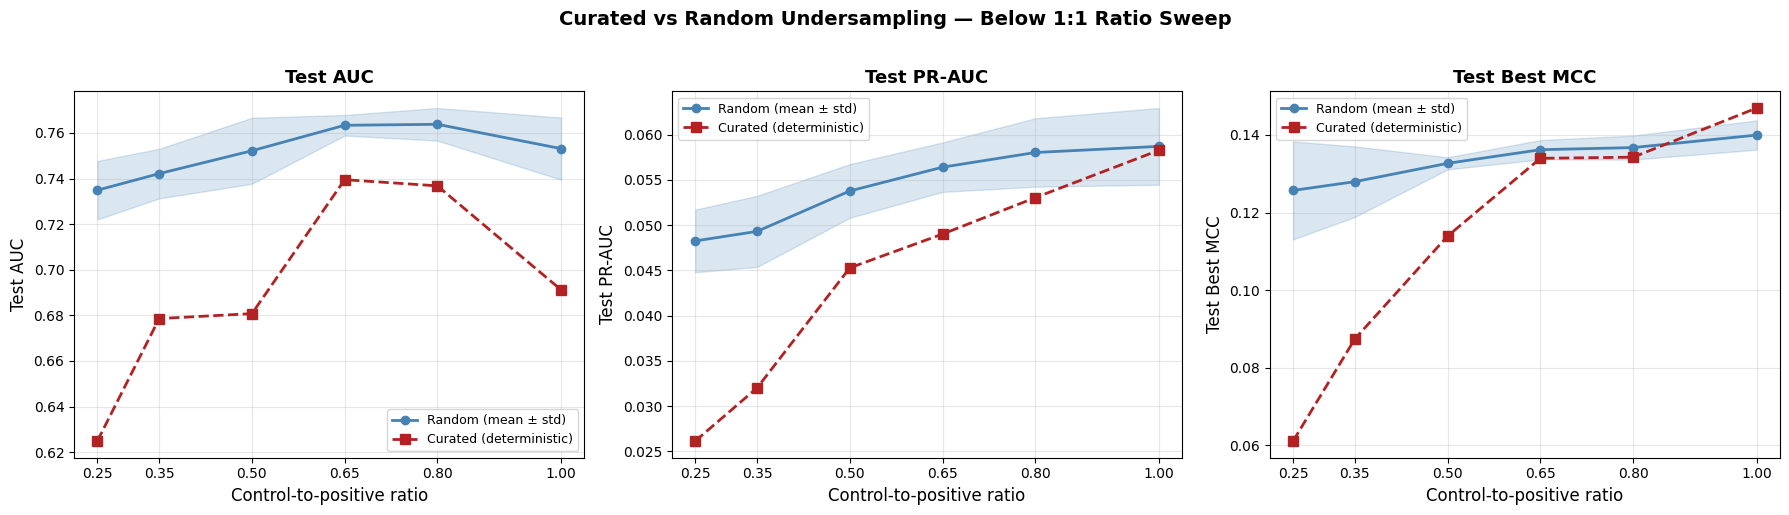

In [2]:
# Debug random undersampling
# ── Load results ────────────────────────────────────────────────────
RESULTS_CSV = "./random_vs_curated_small_ratios/random_vs_curated_comparison.csv"
df = pd.read_csv(RESULTS_CSV)
curated = df[df["method"] == "curated"].copy()
random_ = df[df["method"] == "random"].copy()

# ── 1. Performance comparison plots ────────────────────────────────
metrics_to_plot = [
    ("test_auc",      "Test AUC"),
    ("test_pr_auc",   "Test PR-AUC"),
    ("test_best_mcc", "Test Best MCC"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (metric, label) in zip(axes, metrics_to_plot):
    ratios = sorted(df["ratio"].unique())

    # Random: mean +/- std per ratio
    rnd_means, rnd_stds = [], []
    for r in ratios:
        vals = random_.loc[random_["ratio"] == r, metric].dropna()
        rnd_means.append(vals.mean())
        rnd_stds.append(vals.std())
    rnd_means = np.array(rnd_means)
    rnd_stds = np.array(rnd_stds)

    # Curated: single value per ratio
    cur_vals = []
    for r in ratios:
        v = curated.loc[curated["ratio"] == r, metric]
        cur_vals.append(v.iloc[0] if len(v) else np.nan)
    cur_vals = np.array(cur_vals)

    # Plot random as shaded band + line
    ax.fill_between(ratios, rnd_means - rnd_stds, rnd_means + rnd_stds,
                     alpha=0.20, color="steelblue")
    ax.plot(ratios, rnd_means, "o-", color="steelblue", linewidth=2,
            markersize=6, label="Random (mean ± std)")

    # Plot curated as solid line
    ax.plot(ratios, cur_vals, "s--", color="firebrick", linewidth=2,
            markersize=7, label="Curated (deterministic)")

    ax.set_xlabel("Control-to-positive ratio", fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xticks(ratios)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Curated vs Random Undersampling — Below 1:1 Ratio Sweep",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig("./random_vs_curated_small_ratios/performance_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()



FEATURE PROFILE: CURATED vs RANDOM-ONLY CONTROLS

────────────────────────────────────────────────────────────────────────────────
  ratio=0.25  |  curated n=735  |  random-only n=7,604
────────────────────────────────────────────────────────────────────────────────

  Binary flag prevalence  (curated  vs  random-only  |  delta)
  flag                                                 curated    random     delta
  ------------------------------------------------------------------------------
  has_Arthropathies                                      0.321     0.441   +0.1196 ***
  has_Hypertension                                       0.509     0.396   -0.1127 ***
  has_Obesity                                            0.346     0.240   -0.1057 ***
  has_Type_2_Diabetes                                    0.222     0.118   -0.1033 ***
  direct_msk_is_increasing_Q1_Q2_2017                    0.195     0.291   +0.0966 ***
  has_Hyperlipidemia                                     0.433     0.

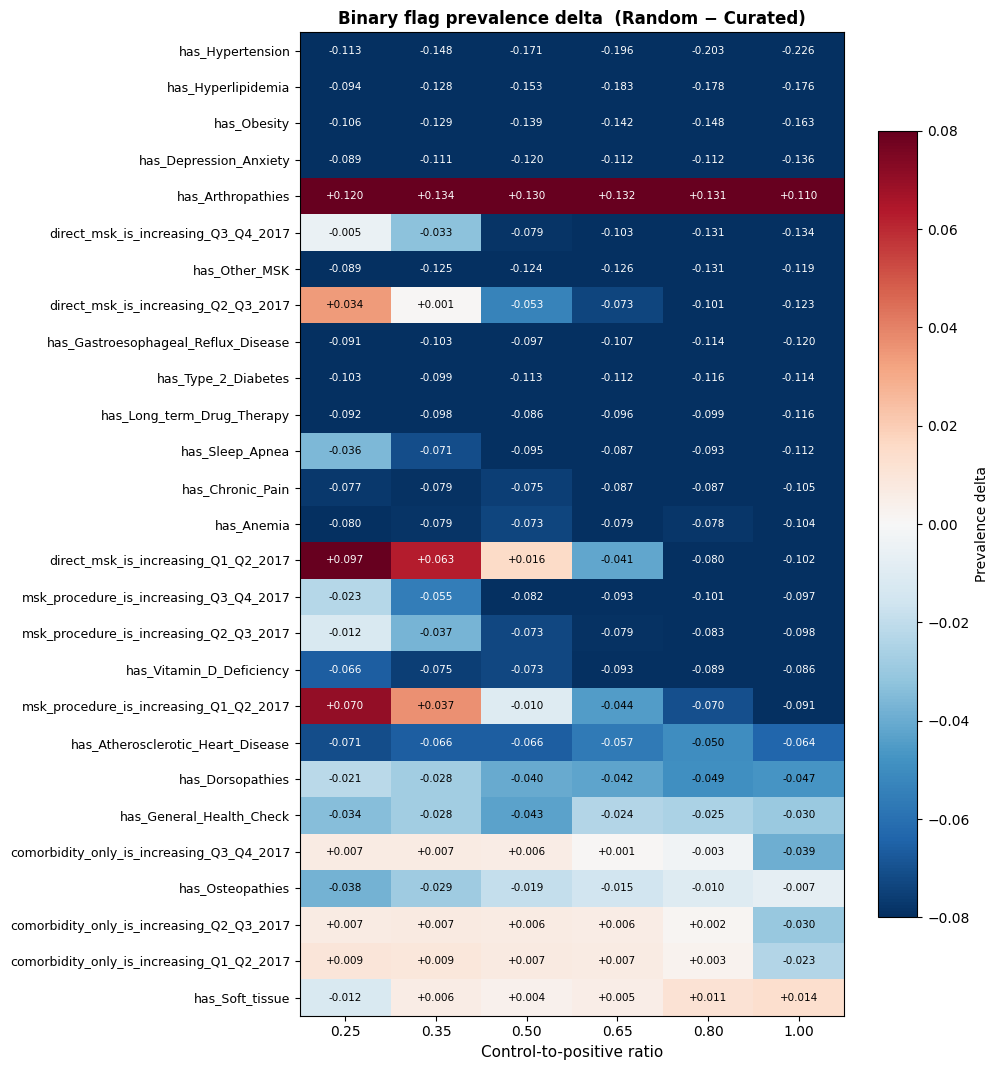

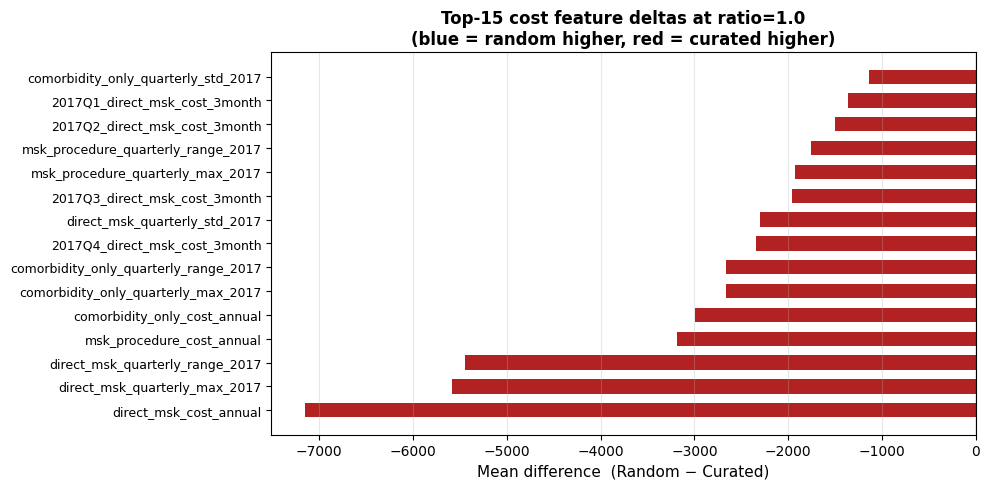


Done.


In [5]:
# ── 2. Feature profile comparison: curated vs random-only controls ──
import glob
df_full = df_og

# Detect target column
target_col_name = ([c for c in df_full.columns
                    if "top" in c.lower() and "2018" in c] + ["top_2_pct_cost_2018"])[0]

# Feature groups
bin_flag_cols = [c for c in df_full.columns
                 if c.startswith("has_") or "THRCLS" in c.upper()
                 or c.endswith("adherent") or c.startswith("early_")
                 or c.startswith("is_") or "is_increasing" in c.lower()
                 or "is_decreasing" in c.lower()]
cost_cols = [c for c in df_full.columns
             if ("cost" in c.lower() or "quarterly" in c.lower()
                 or "increasing" in c.lower() or "decreasing" in c.lower()
                 or "skewness" in c.lower() or "kurtosis" in c.lower()
                 or "cv" in c.lower() or "range" in c.lower())
             and "2018" not in c]

# Drop any string / categorical columns – keep only numeric dtypes
_numeric_cols = set(df_full.select_dtypes(include="number").columns)
bin_flag_cols = [c for c in bin_flag_cols if c in _numeric_cols]
cost_cols     = [c for c in cost_cols     if c in _numeric_cols]

RESULTS_DIR = "./random_vs_curated_small_ratios"
ratios = sorted(df["ratio"].unique())
comparison_rows = []

print("\n" + "="*80)
print("FEATURE PROFILE: CURATED vs RANDOM-ONLY CONTROLS")
print("="*80)

for r in ratios:
    curated_path = os.path.join(RESULTS_DIR, f"curated_r{r:.2f}",
                                f"undersampled_curated_r{r:.2f}.csv")
    if not os.path.exists(curated_path):
        continue

    df_cur = pd.read_csv(curated_path)
    curated_ctrl_ids = set(
        df_cur.loc[df_cur[target_col_name] == 0, "ENROLID"].values
    )

    # Collect union of random-only control IDs across all seeds
    random_only_ids = set()
    seed_dirs = sorted(glob.glob(
        os.path.join(RESULTS_DIR, f"random_r{r:.2f}_s*")
    ))
    for sd in seed_dirs:
        seed_csv = glob.glob(os.path.join(sd, "undersampled_random_r*.csv"))
        if not seed_csv:
            continue
        df_rnd = pd.read_csv(seed_csv[0])
        rnd_ids = set(
            df_rnd.loc[df_rnd[target_col_name] == 0, "ENROLID"].values
        )
        random_only_ids |= (rnd_ids - curated_ctrl_ids)

    # Look up features from full dataset
    cur_df = df_full[df_full["ENROLID"].isin(curated_ctrl_ids)].copy()
    rnd_df = df_full[df_full["ENROLID"].isin(random_only_ids)].copy()

    print(f"\n{'─'*80}")
    print(f"  ratio={r:.2f}  |  curated n={len(cur_df):,}  |  "
          f"random-only n={len(rnd_df):,}")
    print(f"{'─'*80}")

    # ── 2a. Binary flags: prevalence comparison ──
    print(f"\n  Binary flag prevalence  (curated  vs  random-only  |  delta)")
    print(f"  {'flag':<50s}  {'curated':>8s}  {'random':>8s}  {'delta':>8s}")
    print(f"  {'-'*78}")
    flag_diffs = []
    for col in sorted(bin_flag_cols):
        if col not in cur_df.columns:
            continue
        c_mean = cur_df[col].mean()
        r_mean = rnd_df[col].mean()
        delta = r_mean - c_mean
        flag_diffs.append((col, c_mean, r_mean, delta))
    # Sort by absolute delta descending
    flag_diffs.sort(key=lambda x: abs(x[3]), reverse=True)
    for col, c_m, r_m, d in flag_diffs:
        marker = " ***" if abs(d) > 0.03 else ""
        print(f"  {col:<50s}  {c_m:8.3f}  {r_m:8.3f}  {d:+8.4f}{marker}")

    # ── 2b. Cost / numeric aggregates ──
    print(f"\n  Cost & utilization columns  (mean values)")
    print(f"  {'column':<55s}  {'curated':>10s}  {'random':>10s}  {'delta':>10s}  {'delta%':>8s}")
    print(f"  {'-'*98}")
    cost_diffs = []
    for col in sorted(cost_cols):
        if col not in cur_df.columns:
            continue
        c_mean = cur_df[col].mean()
        r_mean = rnd_df[col].mean()
        delta = r_mean - c_mean
        pct = (delta / abs(c_mean) * 100) if abs(c_mean) > 1e-6 else float("nan")
        cost_diffs.append((col, c_mean, r_mean, delta, pct))
    cost_diffs.sort(key=lambda x: abs(x[3]), reverse=True)
    for col, c_m, r_m, d, pct in cost_diffs[:25]:
        pct_str = f"{pct:+7.1f}%" if not np.isnan(pct) else "     N/A"
        print(f"  {col:<55s}  {c_m:10.2f}  {r_m:10.2f}  {d:+10.2f}  {pct_str}")

    # ── 2c. Collect for summary plot ──
    for col in bin_flag_cols:
        if col not in cur_df.columns:
            continue
        comparison_rows.append({
            "ratio": r, "feature": col, "type": "binary_flag",
            "curated_mean": cur_df[col].mean(),
            "random_mean": rnd_df[col].mean(),
        })
    for col in cost_cols:
        if col not in cur_df.columns:
            continue
        comparison_rows.append({
            "ratio": r, "feature": col, "type": "cost",
            "curated_mean": cur_df[col].mean(),
            "random_mean": rnd_df[col].mean(),
        })

# ── 3. Summary heatmap: biggest feature deltas across ratios ───────
if comparison_rows:
    cmp = pd.DataFrame(comparison_rows)
    cmp["delta"] = cmp["random_mean"] - cmp["curated_mean"]

    # --- 3a. Binary flags heatmap ---
    bin_cmp = cmp[cmp["type"] == "binary_flag"].copy()
    pivot_bin = bin_cmp.pivot_table(
        index="feature", columns="ratio", values="delta"
    )
    # Keep flags with max |delta| > 0.01 across any ratio
    keep = pivot_bin.loc[pivot_bin.abs().max(axis=1) > 0.01].copy()
    keep = keep.loc[keep.abs().max(axis=1).sort_values(ascending=False).index]

    if len(keep):
        fig, ax = plt.subplots(figsize=(10, max(4, len(keep) * 0.4)))
        im = ax.imshow(keep.values, cmap="RdBu_r", aspect="auto",
                       vmin=-0.08, vmax=0.08)
        ax.set_yticks(range(len(keep)))
        ax.set_yticklabels(keep.index, fontsize=9)
        ax.set_xticks(range(len(keep.columns)))
        ax.set_xticklabels([f"{c:.2f}" for c in keep.columns], fontsize=10)
        ax.set_xlabel("Control-to-positive ratio", fontsize=11)
        ax.set_title("Binary flag prevalence delta  (Random − Curated)",
                      fontsize=12, fontweight="bold")
        plt.colorbar(im, ax=ax, label="Prevalence delta", shrink=0.8)
        for i in range(keep.shape[0]):
            for j in range(keep.shape[1]):
                v = keep.values[i, j]
                ax.text(j, i, f"{v:+.3f}", ha="center", va="center",
                        fontsize=7.5,
                        color="white" if abs(v) > 0.05 else "black")
        fig.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR,
                    "feature_delta_binary_flags.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()

    # --- 3b. Top cost columns bar chart at ratio=1.0 ---
    cost_cmp = cmp[(cmp["type"] == "cost") & (cmp["ratio"] == 1.0)].copy()
    cost_cmp["abs_delta"] = cost_cmp["delta"].abs()
    cost_cmp = cost_cmp.nlargest(15, "abs_delta")
    if len(cost_cmp):
        fig, ax = plt.subplots(figsize=(10, 5))
        y_pos = np.arange(len(cost_cmp))
        colors = ["steelblue" if d > 0 else "firebrick"
                  for d in cost_cmp["delta"]]
        ax.barh(y_pos, cost_cmp["delta"].values, color=colors, height=0.6)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(cost_cmp["feature"].values, fontsize=9)
        ax.set_xlabel("Mean difference  (Random − Curated)", fontsize=11)
        ax.set_title("Top-15 cost feature deltas at ratio=1.0\n"
                      "(blue = random higher, red = curated higher)",
                      fontsize=12, fontweight="bold")
        ax.axvline(0, color="black", linewidth=0.8)
        ax.grid(True, axis="x", alpha=0.3)
        fig.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR,
                    "feature_delta_cost_top15.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()

print("\nDone.")